![PNS](http://caillau.perso.math.cnrs.fr/logo-pns.png)
## MAM5-INUM - Commande optimale
# TP 3 - Navigation problem (a.k.a. Zermelo-Markov-Dubins), MPC approach

One considers a ship in a constant current $w=(w_x,w_y)$, $|w| \lt 1$. The angle of the velocity (*wrt.* to the water) is controlled, leading to the following dynamics:

$$ \begin{array}{rcl}
     \dot{x}(t) &=& w_x+\cos\theta(t),\quad t \in [0,t_f]\\
     \dot{y}(t) &=& w_y+\sin\theta(t),\\
     \dot{\theta}(t) &=& u(t). 
   \end{array} $$

The turning rate (= curvature of turns) is limited, so $|u(t)| \leq 1$. There boundary conditions at $t=0$ and $t=t_f$ on the position $(x,y)$ and on the angle $\theta$ of the velocity in the water referential. The final time is to be minimised. The problem originates from a collaboration with the French company [CGG](https://www.cgg.com) that is interested in optimal maneuvers for very large ships doing marine prospection.

![ship](ship.png)

In [52]:
using Pkg; Pkg.activate(".")
using JuMP, Ipopt, Plots, OrdinaryDiffEq, LinearAlgebra

# Problem definition
t0 = 0.
x0 = 0. 
y0 = 0.
θ0 = π/7
xf = 4.
yf = 7.
θf =-π/2

function drift(x, y) # current as a function of position
    ε = 10e-2
    w = [ 0.6, 0.4 ]
    δw = ε * [ y, -x ] / sqrt(1+x^2+y^2)
    w = w + δw
    if (w[1]^2 + w[2]^2 >= 1)
        error("|w| >= 1")
    end
    return w
end

  Activating project at `~/commande/tp3`


drift (generic function with 1 method)

In [53]:
# Solver (JuMP)
function solve(x0, y0, θ0, xf, yf, θf, w, P=50; tol=1e-8, max_iter=500, print_level=5)
    
    sys = Model(optimizer_with_attributes(Ipopt.Optimizer,"print_level"=>print_level))
    set_optimizer_attribute(sys, "tol", tol)
    set_optimizer_attribute(sys, "max_iter", max_iter)

    # Variables
    @variables(sys,begin
        x[1:3, 1:P]           # x 
        y[1:3, 1:P]           # y 
        θ[1:3, 1:P]           # theta
        -1 ≤ u[1:3] ≤ 1       # u1 à u3, piecewise constant control
        0 ≤ τ[1:3]            # τ1 à τ3, length of subintervals
        end)

    # Objective
    @objective(sys, Min, τ[1]+τ[2]+τ[3])

    # Constraints 
    @constraints(sys, begin
        x[1, 1] == x0
        y[1, 1] == y0
        θ[1, 1] == θ0
        x[2, 1] == x[1, P]
        y[2, 1] == y[1, P]
        θ[2, 1] == θ[1, P]
        x[3, 1] == x[2, P]
        y[3, 1] == y[2, P]
        θ[3, 1] == θ[2, P]
        x[3, P] == xf
        y[3, P] == yf
        θ[3, P] == θf
        end)

    # Dynamics: Crank-Nicolson scheme
    Δt = 1/P
    for j in 1 : P-1
        @NLconstraints(sys, begin
            # x' = wx + cos(theta)
            x[1, j+1] == x[1, j] + 0.5 * τ[1]*Δt * ( w[1] + cos(θ[1, j]) + w[1] + cos(θ[1, j+1]) )
            x[2, j+1] == x[2, j] + 0.5 * τ[2]*Δt * ( w[1] + cos(θ[2, j]) + w[1] + cos(θ[2, j+1]) )
            x[3, j+1] == x[3, j] + 0.5 * τ[3]*Δt * ( w[1] + cos(θ[3, j]) + w[1] + cos(θ[3, j+1]) )
            # y' = wy + sin(theta) 
            y[1, j+1] == y[1, j] + 0.5 * τ[1]*Δt * ( w[2] + sin(θ[1, j]) + w[2] + sin(θ[1, j+1]) )
            y[2, j+1] == y[2, j] + 0.5 * τ[2]*Δt * ( w[2] + sin(θ[2, j]) + w[2] + sin(θ[2, j+1]) )
            y[3, j+1] == y[3, j] + 0.5 * τ[3]*Δt * ( w[2] + sin(θ[3, j]) + w[2] + sin(θ[3, j+1]) )
            # theta' = u
            θ[1, j+1] == θ[1, j] +       τ[1]*Δt * u[1]
            θ[2, j+1] == θ[2, j] +       τ[2]*Δt * u[2]
            θ[3, j+1] == θ[3, j] +       τ[3]*Δt * u[3]
        end)
    end

    # Solves for the control and state
    println("Solving...")
    optimize!(sys)
    println("Solver status: ", termination_status(sys))
    xs = value.(x)'[:]
    ys = value.(y)'[:]
    θs = value.(θ)'[:]
    us = value.(u)
    τs = value.(τ)
    println("Cost: " , objective_value(sys), "\t τ: ", τs)
    
    return us, τs
    
end

solve (generic function with 2 methods)

In [54]:
# Simulation of the real system
function trajectory(tspan, x0, y0, θ0, us, ts, drift; abstol=1e-12, reltol=1e-12, saveat=[])
    
    function rhs!(dX, X, dummy, t)
        w = drift(X[1], X[2])
        if t < ts[1]
            u = us[1]
        elseif t < ts[2]
            u = us[2]
        else
            u = us[3]
        end
        dX[1] = w[1]+cos(X[3])
        dX[2] = w[2]+sin(X[3])
        dX[3] = u
    end
    
    X0 = [ x0, y0, θ0 ]
    ode = ODEProblem(rhs!, X0, tspan)
    sol = OrdinaryDiffEq.solve(ode, Tsit5(), abstol=abstol, reltol=reltol, saveat=saveat)
    return sol
    
end

trajectory (generic function with 1 method)

In [55]:
# Main loop
Nmax = 50      # max number iterations
ε = 1e-1      # final condition threshold
Δt = 0.5       # fixed time step for MPC
P = 20         # number of points for direct solve

t1 = t0
x1 = x0
y1 = y0
θ1 = θ0

t = [ ]
x = [ ]
y = [ ]
θ = [ ]
u = [ ]

N = 1

while true
    
    w = drift(x1, y1) # current sampled at (x1,y1)
    us, τs = solve(x1, y1, θ1, xf, yf, θf, w, P, print_level=0)
    ts = [ t1+τs[1], t1+τs[1]+τs[2] ]
    tf = t1+τs[1]+τs[2]+τs[3]
    if (t1+Δt < tf)
        t2 = t1+Δt
    else
        t2 = tf
        println("t2=tf: ", t2)
    end
    sol = trajectory((t1, t2), x1, y1, θ1, us, ts, drift)
    t = [ t ; sol.t ]
    x = [ x ; sol[1, :] ]
    y = [ y ; sol[2, :] ]
    θ = [ θ ; sol[3, :] ]
    uu = zeros(length(sol.t))
    uu[ findall(sol.t .< ts[1]) ] .= us[1]
    uu[ findall(ts[1] .<= sol.t .< ts[2]) ] .= us[2]
    uu[ findall(sol.t .>= ts[2]) ] .= us[3]
    u = [ u ; uu ]
    
    t1 = t2
    x1 = x[end]
    y1 = y[end]
    θ1 = θ[end]
    err = norm([ x1, y1, θ1 ] - [ xf, yf, θf ])
    println("N: ", N, "\t err: ", err)
    ((err > ε) && (N <= Nmax)) || break
    N = N+1
    
end

Solving...


Solver status: LOCALLY_SOLVED
Cost: 10.4481366117699	 τ: [2.7793373473408876, 2.7651650124116167, 4.9036342520173966]


N: 1	 err: 7.715108394106521
Solving...
Solver status: LOCALLY_SOLVED
Cost: 11.02247884893982	 τ: [2.2276235750622924, 3.916636072185977, 4.878219201691549]
N: 2	 err: 7.1693729899214675
Solving...
Solver status: 

LOCALLY_SOLVED
Cost: 11.125551041759227	 τ: [1.73868519259491, 4.471857975759081, 4.915007873405237]
N: 3	 err: 6.776192730775302
Solving...
Solver status: 

LOCALLY_SOLVED
Cost: 10.992972923445842	 τ: [1.2551404422786578, 4.7807637532019545, 4.95706872796523]
N: 4	 err: 6.619012385092469
Solving...
Solver status: LOCALLY_SOLVED
Cost: 12.896596942239862	 τ: [7.090797494050364, 5.805799457947603, -9.758105486870401e-9]
N: 5	 err: 6.3918248460870135
Solving...
Solver status: 

...

LOCALLY_INFEASIBLE
Cost: 2.6827682317361057	 τ: [2.682768251709019, -9.991128900508378e-9, -9.981784234717753e-9]
N: 23	 err: 3.5446934690241734
Solving...
Solver status: 

ITERATION_LIMIT
Cost: 2.1568688668688973	 τ: [0.0056769602952811945, 1.9003374141037979, 0.2508544924698184]
N: 24	 err: 2.6114012306190153
Solving...
Solver status: 

LOCALLY_INFEASIBLE
Cost: 1.6290199147230668	 τ: [1.6290199346903964, -9.98378471099863e-9, -9.983544897817091e-9]
N: 25	 err: 1.6842684595423396
Solving...
Solver status: 

LOCALLY_INFEASIBLE
Cost: 1.1061110966902379	 τ: [0.5213077743856959, 0.5848033322898246, -9.985282522856245e-9]
N: 26	 err: 0.8186534760187673
Solving...
Solver status: 

LOCALLY_INFEASIBLE
Cost: 0.5824231348219842	 τ: [0.5824231547963544, -9.983641732093834e-9, -9.990728524564554e-9]
N: 27	 err: 0.0727829954390838


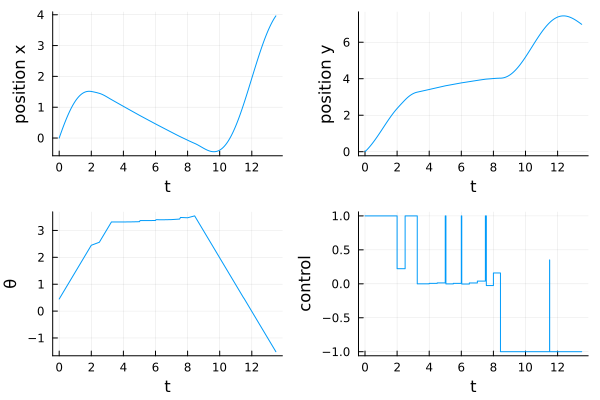

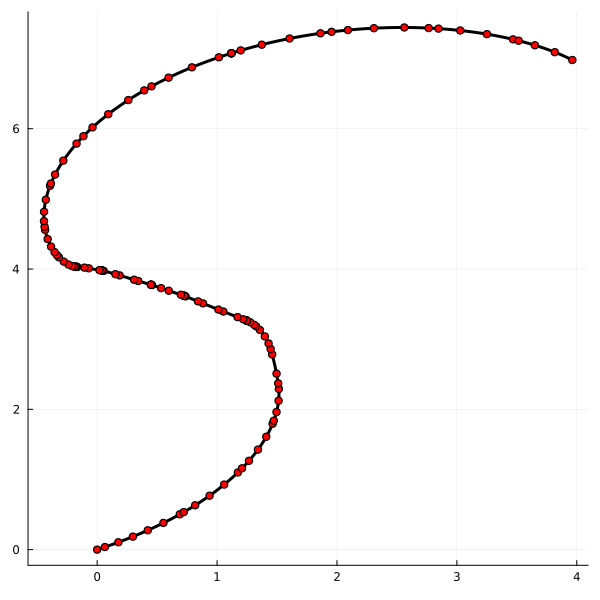

In [56]:
# Plots: states and control
x_plot = plot(t, x, xlabel="t", ylabel="position x", legend=false, fmt=:png)
y_plot = plot(t, y, xlabel="t", ylabel="position y", legend= false, fmt=:png)
θ_plot = plot(t, θ, xlabel="t", ylabel="θ", legend=false, fmt=:png)
u_plot = plot(t, u, xlabel="t", ylabel="control", legend=false, fmt=:png)
display(plot(x_plot, y_plot, θ_plot, u_plot, layout = (2,2)))

# Plots: trajectory 
traj_plot = plot(x, y, color=:black, lw=3)
plot!(size=(600,600))

step = 5
for i = 1:step:length(t)
    plot!([ x[i] ], [ y[i] ], seriestype = :scatter, color =:red, legend = false) 
end
display(traj_plot)